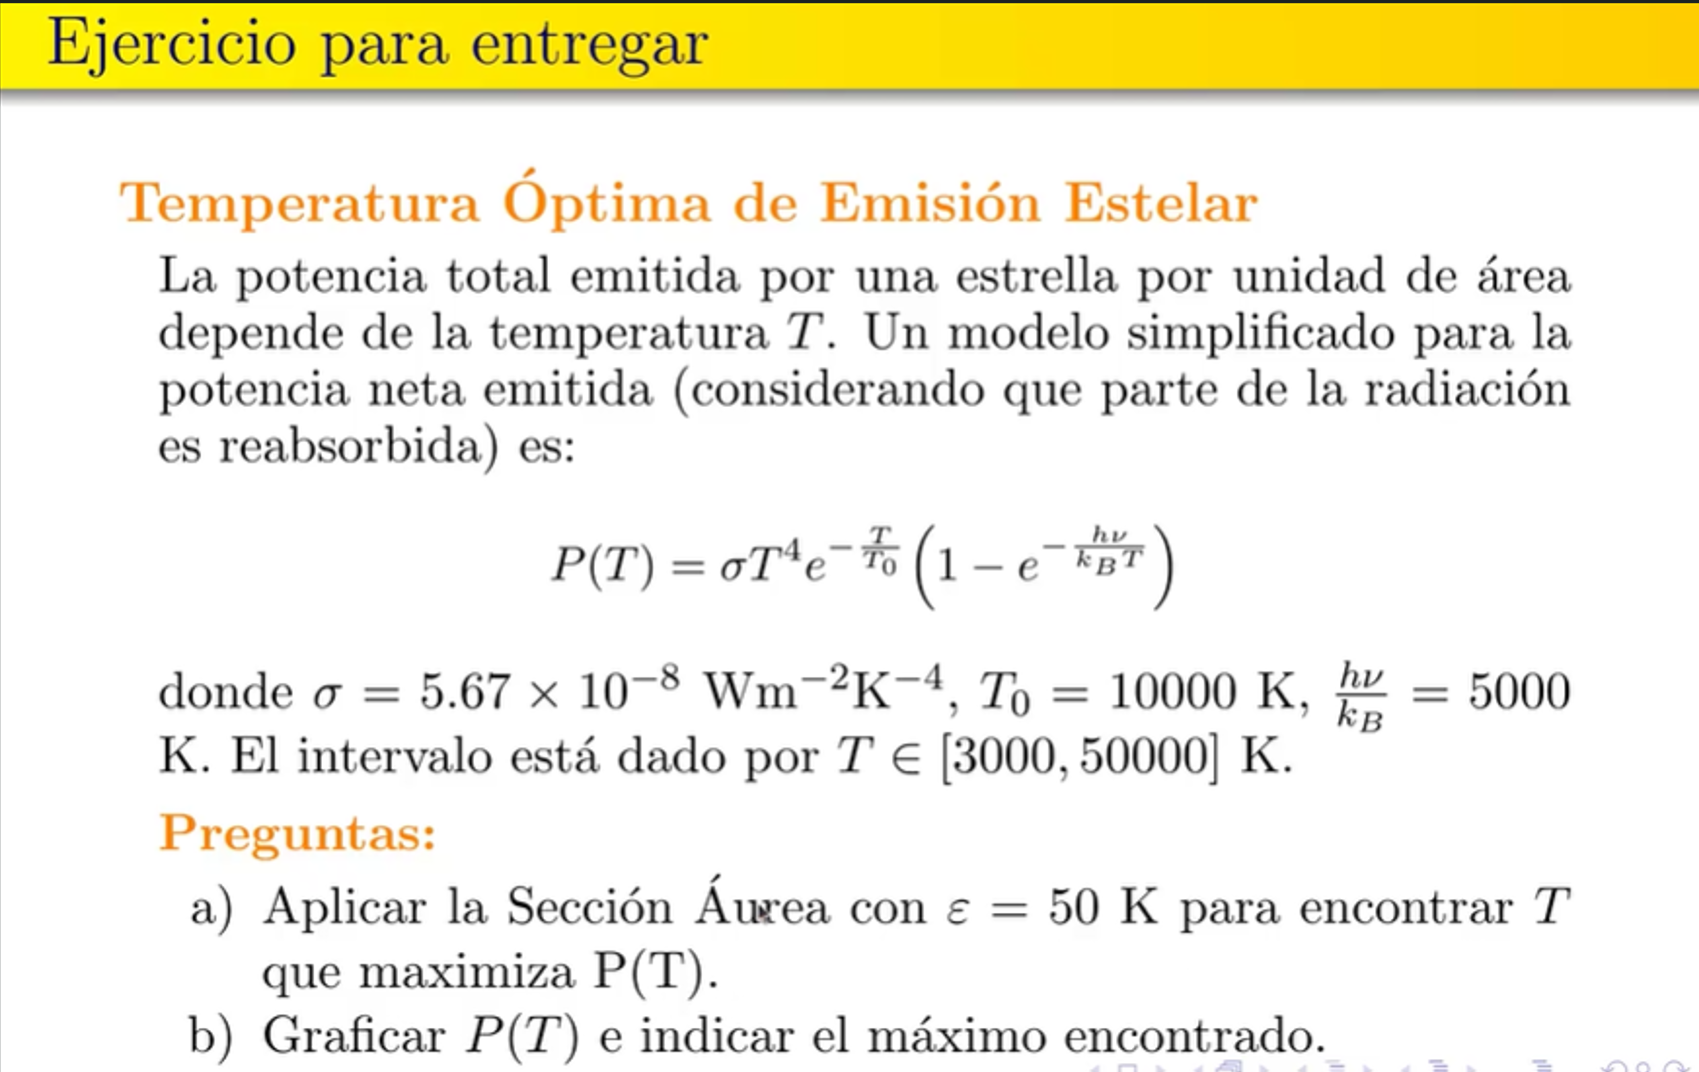

A) BUSQUEDA DEL MAXIMO CON METODO DE SECCION AUREA
Iteracion 1 | xl = 20952.40252875494 | xu = 50000 | Ancho = 29047.59747124506
Iteracion 2 | xl = 20952.40252875494 | xu = 38904.80505750989 | Ancho = 17952.40252875495
Iteracion 3 | xl = 27809.61011501977 | xu = 38904.80505750989 | Ancho = 11095.194942490121
Iteracion 4 | xl = 27809.61011501977 | xu = 34666.8177012846 | Ancho = 6857.207586264831
Iteracion 5 | xl = 27809.61011501977 | xu = 32047.59747124506 | Ancho = 4237.987356225291
Iteracion 6 | xl = 29428.377241205522 | xu = 32047.59747124506 | Ancho = 2619.2202300395365
Iteracion 7 | xl = 30428.83034505931 | xu = 32047.59747124506 | Ancho = 1618.7671261857504
Iteracion 8 | xl = 30428.83034505931 | xu = 31429.28344891309 | Ancho = 1000.4531038537825
Iteracion 9 | xl = 30428.83034505931 | xu = 31047.144367391273 | Ancho = 618.3140223319642
Iteracion 10 | xl = 30665.005285869458 | xu = 31047.144367391273 | Ancho = 382.13908152181466
Iteracion 11 | xl = 30665.005285869458 | xu = 30901.

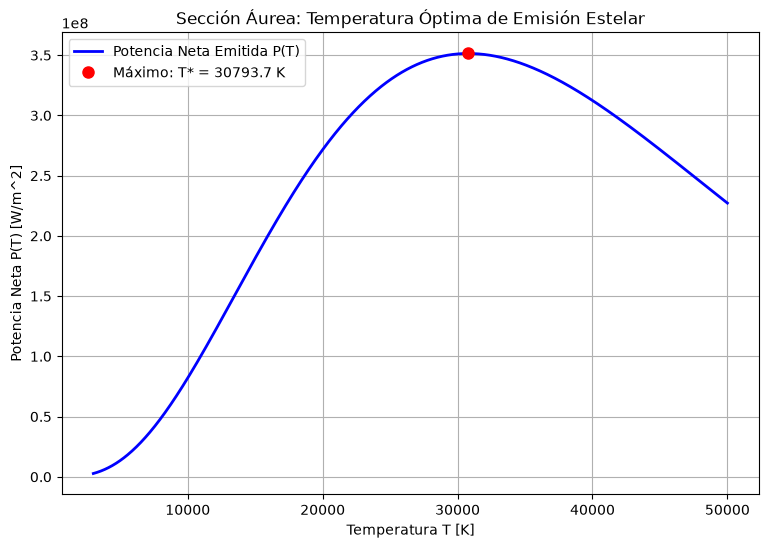

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros físicos del problema
sigma = 5.67e-8
T0 = 10000
hv_kB = 5000

# Inicialización del intervalo [xl, xu] y tolerancia
xl = 3000
xu = 50000
epsilon = 50

# Constante de la sección áurea
R = (np.sqrt(5.0) - 1.0) / 2.0

# Paso 1: Puntos intermedios iniciales
d = R * (xu - xl)
x1 = xl + d
x2 = xu - d

# Paso 2: Evaluación inicial de la función
f1 = sigma * (x1**4) * np.exp(-x1 / T0) * (1.0 - np.exp(-hv_kB / x1))
f2 = sigma * (x2**4) * np.exp(-x2 / T0) * (1.0 - np.exp(-hv_kB / x2))

# Contador de iteraciones
iteracion = 0

print("A) BUSQUEDA DEL MAXIMO CON METODO DE SECCION AUREA")

# Bucle principal del algoritmo de la Sección Áurea
while (xu - xl) >= epsilon:
    iteracion = iteracion + 1
    
    # Paso 3: Actualizar el intervalo
    if f1 > f2:
        xl = x2
        x2 = x1
        f2 = f1
        d = R * (xu - xl)
        x1 = xl + d
        f1 = sigma * (x1**4) * np.exp(-x1 / T0) * (1.0 - np.exp(-hv_kB / x1))
    else:
        xu = x1
        x1 = x2
        f1 = f2
        d = R * (xu - xl)
        x2 = xu - d
        f2 = sigma * (x2**4) * np.exp(-x2 / T0) * (1.0 - np.exp(-hv_kB / x2))

    print("Iteracion", iteracion, "| xl =", xl, "| xu =", xu, "| Ancho =", xu - xl)

# Estimación final de la temperatura óptima y la potencia máxima
T_optima = (xl + xu) / 2.0
P_maxima = sigma * (T_optima**4) * np.exp(-T_optima / T0) * (1.0 - np.exp(-hv_kB / T_optima))

print("RESULTADOS DEL INCISO A)")
print("Temperatura óptima T * =", T_optima, "K")
print("Potencia máxima P(T*) =", P_maxima, "W/m^2")
print("Ancho del intervalo final =", xu - xl, "K")
print("Iteraciones realizadas =", iteracion)


# b) Graficar
print("B) GRAFICA DE P(T) Y MAXIMO ENCONTRADO")

# Malla continua de temperaturas para la curva
T_grafica = np.linspace(3000.0, 50000.0, 1000)
P_grafica = sigma * (T_grafica**4) * np.exp(-T_grafica / T0) * (1.0 - np.exp(-hv_kB / T_grafica))

plt.figure(figsize=(9, 6))
plt.plot(T_grafica, P_grafica, 'b-', linewidth=2.0, label='Potencia Neta Emitida P(T)')
plt.plot(T_optima, P_maxima, 'ro', markersize=8, label=f'Máximo: T* = {T_optima:.1f} K')

plt.xlabel('Temperatura T [K]')
plt.ylabel('Potencia Neta P(T) [W/m^2]')
plt.title('Sección Áurea: Temperatura Óptima de Emisión Estelar')
plt.grid(True)
plt.legend()
plt.show()